# EDA: KuaiRand

Exploring the dataset a bit to see if we can detect the bias in the standard logs.

Run `krec ingest` first. 

In [1]:
%matplotlib inline
import os

from krec import eda
from krec.config import load_config

cfg = load_config(
    os.environ.get("KREC_CONFIG", "configs/pure.yaml"),
    root=os.environ.get("KREC_ROOT"),
)
cfg.dataset.name

'pure'

## 1. What's in the data

Rows, users and items per split and source. Random-exposure logs start on `04-22`, so
the training window has far fewer of them.

In [2]:
eda.overview(cfg)

,source,split,rows,users,items,first_day,last_day
0,standard,train,1303064,26768,7548,2022-04-09,2022-04-30
1,standard,val,76887,18911,4919,2022-05-01,2022-05-04
2,standard,test,56658,17396,4956,2022-05-05,2022-05-08
3,random,train,400649,23073,7557,2022-04-22,2022-04-30
4,random,val,366088,24284,7357,2022-05-01,2022-05-04
5,random,test,419322,24462,7295,2022-05-05,2022-05-08


### Daily volume

Impressions per day, by source. Pure only keeps logs for the 7,583 videos in the
random-exposure candidate pool, so the standard curve shows how much exposure
the policy gave those particular videos over time.

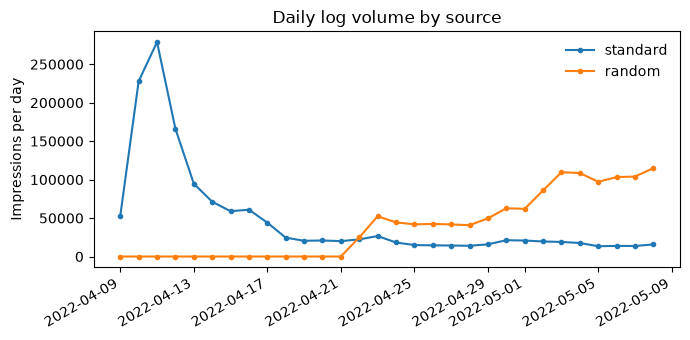

In [3]:
volume = eda.daily_volume(cfg)
eda.daily_volume_figure(volume)

In [4]:
volume.T

date,2022-04-09,2022-04-10,2022-04-11,2022-04-12,2022-04-13,2022-04-14,2022-04-15,2022-04-16,2022-04-17,2022-04-18,...,2022-04-29,2022-04-30,2022-05-01,2022-05-02,2022-05-03,2022-05-04,2022-05-05,2022-05-06,2022-05-07,2022-05-08
source,,,,,,,,,,,,,,,,,,,,,
random,0,0,0,0,0,0,0,0,0,0,...,49595,62716,62044,85874,109627,108543,97170,103245,103982,114925
standard,52736,227808,278835,166076,94711,71252,58892,60904,44023,24560,...,15839,21204,20790,19554,18943,17600,13390,13834,13687,15747


## 2. Policy-chosen vs randomly-shown items

Same users, same days (only the days when both logs exist).

In [5]:
eda.feedback_rates(cfg)

,impressions,click_rate,long_view_rate,like_rate,play_ratio
source,,,,,
standard,295497,0.445003,0.313381,0.017713,0.383816
random,1186059,0.176158,0.084961,0.004798,0.226775


### Is the comparison like-for-like?

Two things could inflate the gap above without the policy choosing better items:

- **UI mix.** `is_click` means a tap in the two-column UI but a "valid play" in the
  single-column UI. If the sources are spread differently across tabs, their click
  rates aren't measuring the same thing.
- **User mix.** The rates above are averaged over impressions, so heavy users
  dominate. Comparing within the same users, each counted once, removes that.

In [6]:
eda.tab_mix(cfg)

,standard_share,random_share,standard_click_rate,random_click_rate
tab,,,,
0,0.095006,NaN,0.084491,NaN
1,0.756397,0.993226,0.498101,0.177286
2,0.030704,0.000644,0.480436,0.113874
3,0.001489,NaN,0.022727,NaN
4,0.059699,NaN,0.597925,NaN
5,0.002596,NaN,0.242503,NaN
6,0.044379,NaN,0.164023,NaN
7,0.000579,NaN,0.391813,NaN
8,0.004596,NaN,0.039764,NaN


In [7]:
eda.within_user_rates(cfg)

,users,standard_rate,random_rate,mean_difference,share_users_higher_on_standard
label,,,,,
is_click,18742,0.456836,0.161692,0.295144,0.922153
long_view,18742,0.327919,0.077292,0.250627,0.888059


## 3. How concentrated is exposure?

The share of impressions going to the most-shown items, for each source. Items a
source never showed count as zero.

In [8]:
exposure = eda.item_exposure(cfg)
eda.exposure_concentration(exposure)

,items_shown,top_1pct_share,gini
source,,,
standard,6618,0.184943,0.763440
random,7583,0.012537,0.080809


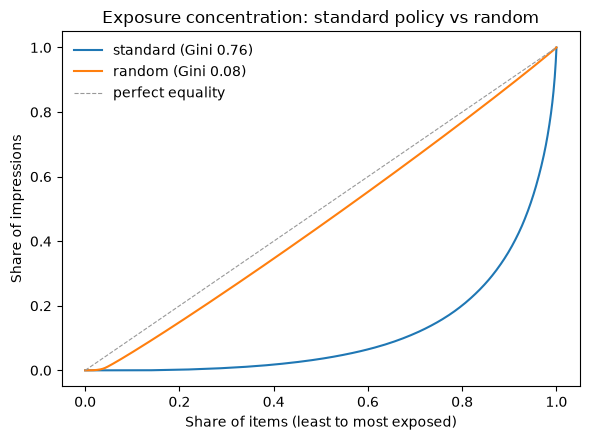

In [9]:
eda.lorenz_figure(exposure)

## 4. How strongly does the policy's exposure track quality?

Items with enough random impressions, bucketed by how often the standard policy
showed them. The random click rate is a measure of how much users like an item when
it is shown regardless of the policy. Compare how much it rises across buckets with
how much exposure rises: the question is not whether exposure tracks quality, but
in what proportion.

In [10]:
eda.exposure_vs_quality(cfg)

,items,median_standard_impr,random_click_rate
standard_exposure_bucket,,,
1,1485,0.0,0.145713
2,1485,3.0,0.150399
3,1485,9.0,0.168286
4,1484,26.0,0.185682
5,1484,99.0,0.236372


## 5. Sparsity

In [11]:
eda.sparsity(cfg)

,density,median_impr_per_user,p90_impr_per_user
source,,,
standard,0.006725,39.0,115.0
random,0.005732,22.0,96.0


## Findings

1. **Standard volume is front-loaded.** 
    81% of standard train rows fall in 04-09..04-17. In val and test, the random log is 5–7× the standard log. 

    *Consequence:* Models fit on standard logs mostly learn from those first days, and random-log metrics will be the more precise ones.
2. **Policy-chosen items get far more engagement.** 
    Click rate is 0.445 vs 0.176. The gap holds within tab 1 and within the same users. 

    *Consequence:* Evaluating on standard logs rewards imitating the policy, so unbiased evaluation uses the random logs, and tab must be held fixed or modelled when comparing rates.
3. **Exposure is concentrated under the policy and near-uniform under random.** 
    The Gini is 0.76 vs 0.08, and in that window the policy never showed 965 of the 7,583 items. 

    *Consequence:* The random logs work as unbiased eval sets, but reweighting standard logs can't correct for items the policy never showed.
4. **Exposure grows far faster than quality.** 
    Median standard impressions go from 0 to 99 across buckets while the random click rate only rises 1.6×. 
    
    *Consequence:* A popularity baseline should still beat random on unbiased data; the bias is in how much a model trained on standard logs over-trusts exposure. 
5. **Interactions are sparse.** 
    The median user has 39 standard and 22 random impressions. 

    *Consequence:* GAUC will be noisy for light users, so it's reported alongside pooled AUC.